In [1]:
import tifffile as tiff
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [31]:
image = tiff.imread("F:/Xinlin_Gao/AA_16gene_mouse_ZHOU/data_extraction/raw_reads_by_round_tile/round1/Tile_29/ch04_Tile_29_channel405.tif")
image.shape

(40, 2720, 2720)

In [22]:
def is_blurry(image, threshold = 100.0):
    lap_var = cv2.Laplacian(image, cv2.CV_64F).var()
    return lap_var < threshold, lap_var
def tenengrad_blur_score(image):
    gx = cv2.Sobel(image, cv2.CV_64F, 1, 0)
    gy = cv2.Sobel(image, cv2.CV_64F, 0, 1)
    fm = np.mean(gx**2 + gy**2)
    return fm
def brenner_focus_measure(image):
    return np.sum((image[:, 2:] - image[:, :-2]) ** 2)


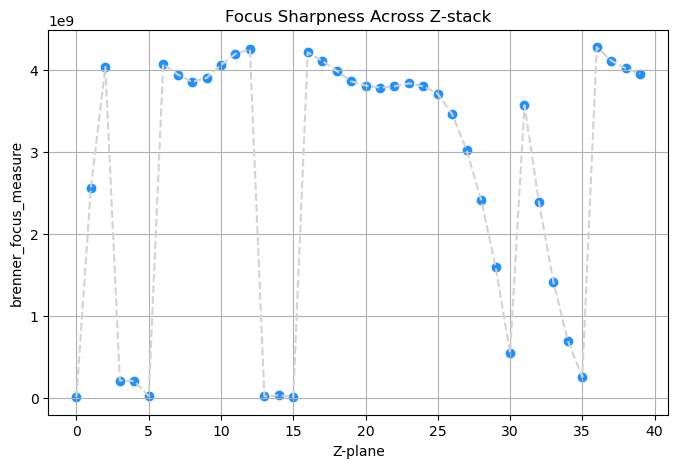

In [32]:
scores = []
for i in range(0, 40):
    z = image[i,:,:]
    score = brenner_focus_measure(z)
    scores.append(score)

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(range(40), scores, color='dodgerblue')
plt.plot(range(40), scores, color='lightgray', linestyle='--')
plt.xlabel("Z-plane")
plt.ylabel("brenner_focus_measure")
plt.title("Focus Sharpness Across Z-stack")
plt.grid(True)
plt.show()

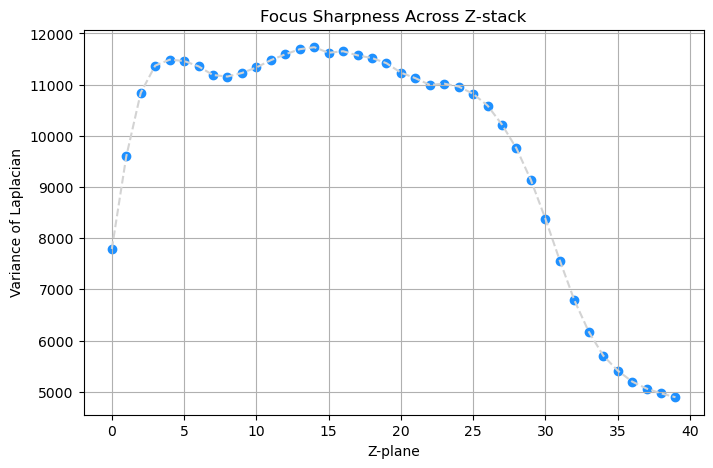

In [ ]:
scores = []
for i in range(0, 40):
    z = image[i,:,:]
    _, score = is_blurry(z)
    scores.append(score)

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(range(40), scores, color='dodgerblue')
plt.plot(range(40), scores, color='lightgray', linestyle='--')
plt.xlabel("Z-plane")
plt.ylabel("Variance of Laplacian")
plt.title("Focus Sharpness Across Z-stack")
plt.grid(True)
plt.show()

In [59]:
max_scores = []

for tile in range(0,66):
    scores = []
    image = tiff.imread(f"F:/Xinlin_Gao/AA_16gene_mouse_ZHOU/data_extraction/raw_reads_by_round_tile/round1/Tile_{tile}/ch04_Tile_{tile}_channel405.tif")
    for i in range(0, 40):
        z = image[i,:,:]
        _, score = is_blurry(z)
        scores.append(score)
    sorted_indices = np.argsort(np.array(scores))[::-1] 
    one = sorted_indices[0].astype(int)
    two = sorted_indices[1].astype(int)
    if two>20:
        maxi = two+one/2
        if two<2:
            maxi = max(two,one)
    else:
        maxi = one
    max_scores.append(maxi)
    if maxi > 17:
        print(f"Warning! {tile} has {maxi} number of out of focus layers. Check manually!")



Warning! 2 has 38.5 number of out of focus layers. Check manually!
Warning! 4 has 53.5 number of out of focus layers. Check manually!
Warning! 5 has 32.5 number of out of focus layers. Check manually!
Warning! 6 has 35.0 number of out of focus layers. Check manually!
Warning! 8 has 32.0 number of out of focus layers. Check manually!
Warning! 9 has 34.0 number of out of focus layers. Check manually!
Warning! 10 has 32.5 number of out of focus layers. Check manually!
Warning! 11 has 21 number of out of focus layers. Check manually!
Warning! 12 has 36.5 number of out of focus layers. Check manually!
Warning! 13 has 35.0 number of out of focus layers. Check manually!
Warning! 16 has 19 number of out of focus layers. Check manually!
Warning! 49 has 20 number of out of focus layers. Check manually!


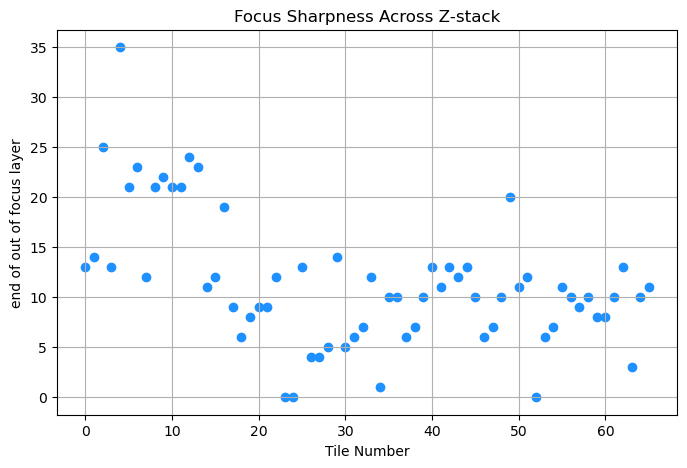

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(range(0,66), max_scores, color='dodgerblue')
plt.xlabel("Tile Number")
plt.ylabel("end of out of focus layer")
plt.title("Focus Sharpness Across Z-stack")
plt.grid(True)
plt.show()